## **Clinical trial analysis**

The notebook performs a bias audit on a clinical dataset to identify disparities across gender, race, and disease stage in relation to patient outcomes. It combines exploratory data analysis, fairness metrics, statistical testing, and bias mitigation techniques.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Clinical Data_Discovery_Cohort.csv')
display(df.head())

,PatientID,Specimen date,Dead or Alive,Date of Death,Date of Last Follow Up,sex,race,Stage,Event,Time
0,1,3/17/2003,Dead,2/24/2010,2/24/2010,F,B,pT2N2MX,1,2536
1,2,6/17/2003,Dead,11/12/2004,11/12/2004,M,W,T2N2MX,1,514
2,3,9/9/2003,Dead,8/1/2009,8/1/2009,F,B,T2N1MX,1,2153
3,4,10/14/2003,Dead,12/29/2006,12/29/2006,M,W,pT2NOMX,1,1172
4,5,12/1/2003,Dead,1/31/2004,1/31/2004,F,W,T2NOMX,1,61


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   PatientID               30 non-null     int64 
 1   Specimen date           30 non-null     object
 2   Dead or Alive           30 non-null     object
 3   Date of Death           30 non-null     object
 4   Date of Last Follow Up  30 non-null     object
 5   sex                     30 non-null     object
 6   race                    30 non-null     object
 7   Stage                   30 non-null     object
 8   Event                   30 non-null     int64 
 9   Time                    30 non-null     int64 
dtypes: int64(3), object(7)
memory usage: 2.5+ KB


Analyzing the dataset from `/content/Clinical Data_Discovery_Cohort.csv` to identify and visualize potential bias patterns in gender, race, and disease stage distributions, and how these factors relate to patient outcomes ('Dead or Alive').

calculating the value counts of the 'sex' column to understand the distribution of genders in the dataset.



In [ ]:
gender_counts = df['sex'].value_counts()
print("Gender Distribution:\n", gender_counts)

Gender Distribution:
 sex
M    16
F    14
Name: count, dtype: int64


Now that the gender counts have been calculated, we create a bar plot to visualize the distribution of gender as instructed, using seaborn.countplot().



/tmp/ipython-input-2608698954.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='viridis')


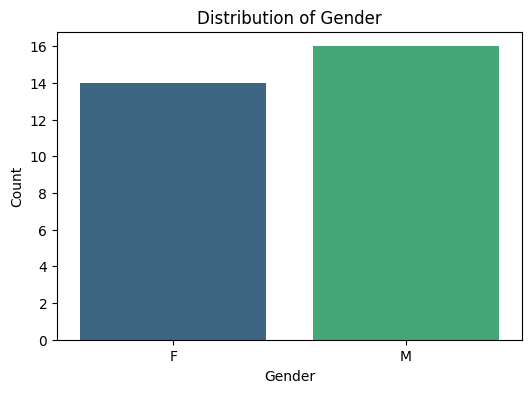

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sex', palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


The previous code generated a FutureWarning because `palette` was used without `hue`. To fix this and comply with the recommended usage for future versions of seaborn, we explicitly set `hue='sex'` and `legend=False` in the `sns.countplot` function.



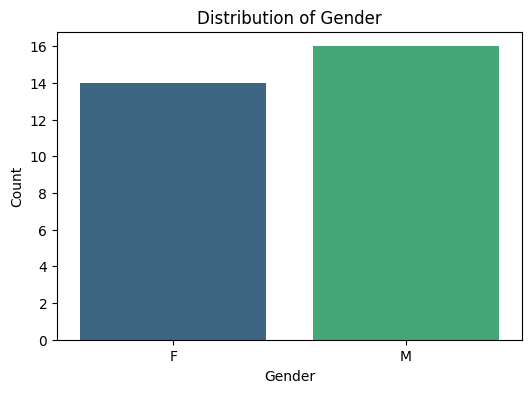

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sex', hue='sex', palette='viridis', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Now we are examining the distribution of the 'race' variable in the dataset and create a bar plot to visualize racial representation. This helps identify any potential racial imbalance.


First, we calculate the value counts of the 'race' column to understand the distribution of racial groups in the dataset, as per the first instruction.



In [ ]:
race_counts = df['race'].value_counts()
print("Race Distribution:\n", race_counts)

Race Distribution:
 race
W    21
B     7
O     1
A     1
Name: count, dtype: int64


Now that the racial counts have been calculated, we will create a bar plot to visualize the distribution of race as instructed, using seaborn.countplot().



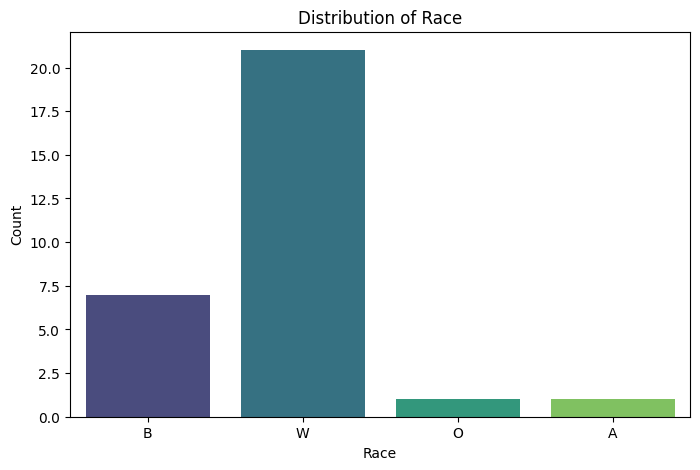

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='race', hue='race', palette='viridis', legend=False)
plt.title('Distribution of Race')
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

Examining the distribution of the 'Stage' variable in the dataset and create a bar plot to visualize the distribution of disease stages. This helps understand the prevalence of different stages.


First, we will calculate the value counts of the 'Stage' column to understand the distribution of disease stages in the dataset, as per the first instruction.



In [ ]:
stage_counts = df['Stage'].value_counts()
print("Disease Stage Distribution:\n", stage_counts)

Disease Stage Distribution:
 Stage
T2N0         7
PT1PN0       5
T1N0         3
PT2PN0       3
pT2NOMX      1
pT2N2MX      1
T2N1MX       1
T2N2MX       1
T1NOMX       1
pT2pN0       1
T2NOMX       1
pT1pN0       1
PT2PN1       1
 pT3N0Mx     1
PT3PN0       1
PT4PN1       1
Name: count, dtype: int64


Now that the stage counts have been calculated, we will create a bar plot to visualize the distribution of disease stages as instructed, using seaborn.countplot().



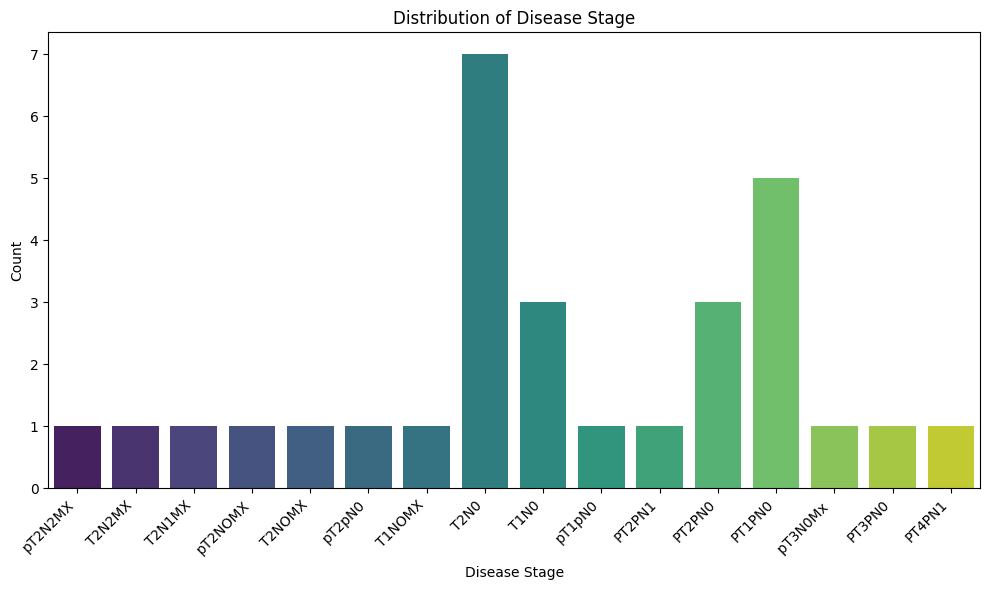

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Stage', hue='Stage', palette='viridis', legend=False)
plt.title('Distribution of Disease Stage')
plt.xlabel('Disease Stage')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Investigate how the 'Dead or Alive' outcome is distributed across different 'sex' categories. Visualize this relationship using a count plot or stacked bar chart to identify any gender-related disparities in outcomes.


First, we will calculate the cross-tabulation of 'sex' and 'Dead or Alive' to understand the joint distribution of these two variables, as per the first instruction.

Now, we will calculate the cross-tabulation of 'sex' and 'Dead or Alive' to understand their joint distribution, as specified in the instructions.



In [ ]:
gender_outcome_crosstab = pd.crosstab(df['sex'], df['Dead or Alive'])
print("Gender vs. Outcome Crosstabulation:\n", gender_outcome_crosstab)

Gender vs. Outcome Crosstabulation:
 Dead or Alive  Alive  Dead
sex                       
F                  5     9
M                  4    12


Now that the cross-tabulation of gender and outcome has been calculated, we will create a count plot to visualize the distribution of 'Dead or Alive' outcomes by 'sex', as instructed. This will fulfill the visualization requirement of the subtask.



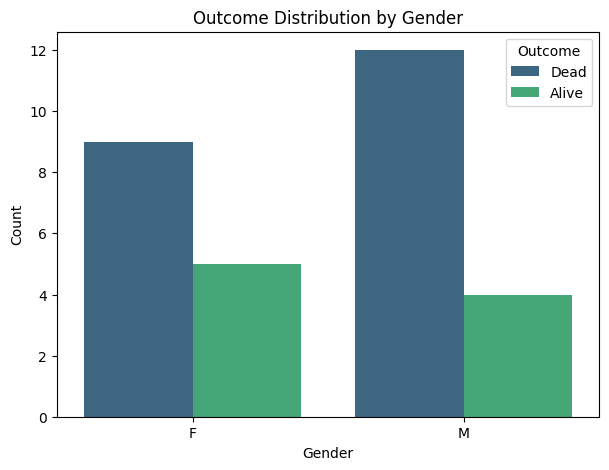

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='sex', hue='Dead or Alive', palette='viridis')
plt.title('Outcome Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Outcome')
plt.show()

Investigating how the 'Dead or Alive' outcome is distributed across different 'race' categories. Visualize this relationship using a count plot or stacked bar chart to identify any race-related disparities in outcomes.


First, we will calculate the cross-tabulation of 'race' and 'Dead or Alive' to understand the joint distribution of these two variables, as per the first instruction.



In [ ]:
race_outcome_crosstab = pd.crosstab(df['race'], df['Dead or Alive'])
print("Race vs. Outcome Crosstabulation:\n", race_outcome_crosstab)

Race vs. Outcome Crosstabulation:
 Dead or Alive  Alive  Dead
race                      
A                  0     1
B                  2     5
O                  0     1
W                  7    14


Now that the cross-tabulation of race and outcome has been calculated, we will create a count plot to visualize the distribution of 'Dead or Alive' outcomes by 'race', as instructed. This will fulfill the visualization requirement of the subtask.



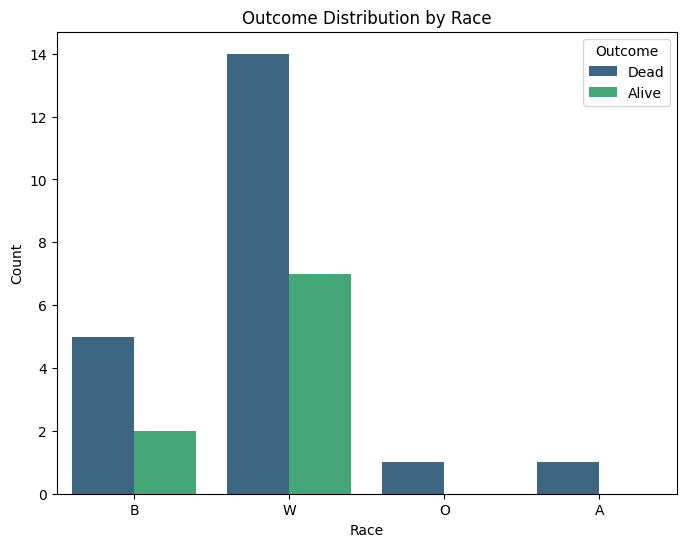

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='race', hue='Dead or Alive', palette='viridis')
plt.title('Outcome Distribution by Race')
plt.xlabel('Race')
plt.ylabel('Count')
plt.legend(title='Outcome')
plt.show()

Investigating how the 'Dead or Alive' outcome is distributed across different 'Stage' categories. Visualize this relationship using a count plot or stacked bar chart to identify any stage-related disparities in outcomes.


First, we will calculate the cross-tabulation of the 'Stage' and 'Dead or Alive' columns using `pd.crosstab()` to understand the joint distribution of these two variables, as per the first instruction.

Now, we will calculate the cross-tabulation of 'Stage' and 'Dead or Alive' and print the result, as instructed.



In [ ]:
stage_outcome_crosstab = pd.crosstab(df['Stage'], df['Dead or Alive'])
print("Stage vs. Outcome Crosstabulation:\n", stage_outcome_crosstab)

Stage vs. Outcome Crosstabulation:
 Dead or Alive  Alive  Dead
Stage                     
 pT3N0Mx           1     0
PT1PN0             1     4
PT2PN0             2     1
PT2PN1             0     1
PT3PN0             0     1
PT4PN1             0     1
T1N0               1     2
T1NOMX             0     1
T2N0               3     4
T2N1MX             0     1
T2N2MX             0     1
T2NOMX             0     1
pT1pN0             0     1
pT2N2MX            0     1
pT2NOMX            0     1
pT2pN0             1     0


Now that the cross-tabulation of stage and outcome has been calculated, we will create a count plot to visualize the distribution of 'Dead or Alive' outcomes by 'Stage', as instructed. This will fulfill the visualization requirement of the subtask.



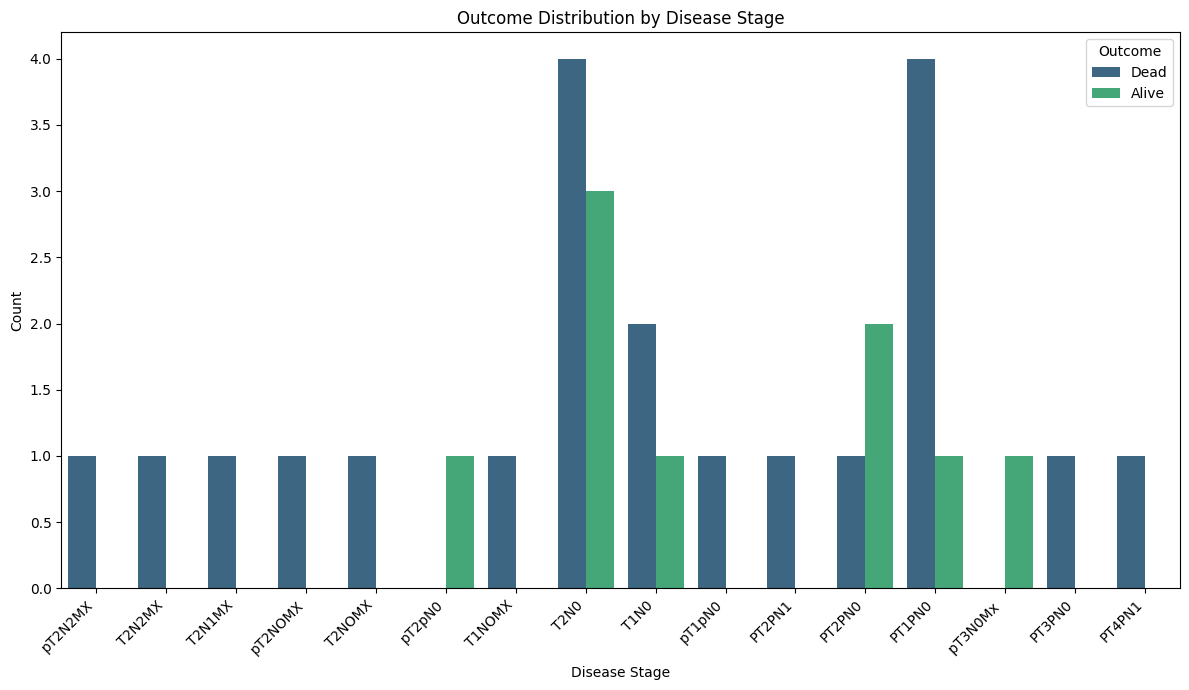

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Stage', hue='Dead or Alive', palette='viridis')
plt.title('Outcome Distribution by Disease Stage')
plt.xlabel('Disease Stage')
plt.ylabel('Count')
plt.legend(title='Outcome')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Gender Distribution and Outcome:** The dataset contains a slightly higher number of males (16) than females (14). In terms of outcomes, 64.3% of females (9 out of 14) and 75% of males (12 out of 16) were recorded as 'Dead'. This suggests a higher proportion of 'Dead' outcomes among males in this cohort.
*   **Race Distribution and Outcome:** A significant racial imbalance was observed, with 'W' (White) being the most prevalent group (21 individuals), followed by 'B' (Black) with 7 individuals, and 'O' (Other) and 'A' (Asian) each with only 1 individual.
    *   Within this cohort, 'W' patients had 7 'Alive' and 14 'Dead' outcomes.
    *   'B' patients had 2 'Alive' and 5 'Dead' outcomes.
    *   'A' and 'O' patients each had 0 'Alive' and 1 'Dead' outcome.
    *   Across all represented racial groups, the number of 'Dead' outcomes was consistently higher than or equal to 'Alive' outcomes.
*   **Disease Stage Distribution and Outcome:** The dataset showed a diverse distribution of disease stages, with `T2N0` (7 occurrences) and `PT1PN0` (5 occurrences) being the most frequent.
    *   The outcome distribution varied significantly by stage. Some stages, like `pT3N0Mx` and `pT2pN0`, had only 'Alive' outcomes within the dataset, while others, such as `PT2PN1`, `PT3PN0`, and `pT1pN0`, exclusively showed 'Dead' outcomes.
    *   Stages like `PT1PN0`, `T1N0`, and `T2N0` showed a mix of outcomes but often leaned towards a higher proportion of 'Dead' outcomes.

### Insights or Next Steps

*   The observed racial imbalance, particularly the dominance of the 'W' group and minimal representation of 'A' and 'O' groups, suggests a potential sampling bias. Further data collection should aim for a more diverse and representative sample to ensure generalizability and avoid skewed conclusions related to race.
*   The significant variation in outcomes across different disease stages, from exclusively 'Alive' to exclusively 'Dead' in certain stages, indicates that disease stage is a critical prognostic factor. Future analyses should delve deeper into the characteristics of patients within each stage to understand the factors contributing to these outcome disparities.


# Task
Now we will perform a comprehensive bias audit on the `/content/Clinical Data_Discovery_Cohort.csv` dataset. This involves calculating at least three quantitative fairness metrics for 'sex' and 'race' with respect to the 'Dead or Alive' outcome, conducting statistical tests (e.g., Chi-squared) to validate identified bias patterns across 'sex', 'race', and 'Stage' concerning the 'Dead or Alive' outcome, and applying two bias mitigation techniques: one to address racial imbalance (oversampling underrepresented groups: 'A', 'O', 'B') and another to address outcome imbalance (oversampling the 'Alive' outcome class). Visualize the distributions after each mitigation. Finally, provide a comprehensive summary of the audit, including review of identified biases, fairness metrics, statistical validation, impact of mitigation strategies, recommendations for dataset improvements, discussion of real-world implications and potential harms, and an ethics framework for this clinical data analysis.

## Initial Data Exploration and Bias Identification

Reviewing the initial distributions of 'sex', 'race', and 'Stage' and their relationship with 'Dead or Alive' outcomes, confirming existing bias patterns identified in the previous steps. This covers the 'selection of a potentially biased dataset' and the initial 'visual and statistical representation of bias patterns'.


## Implement Quantitative Fairness Metrics

Calculating at least three quantitative fairness metrics (Statistical Parity Difference, Disparate Impact, Equal Opportunity Difference for the 'Alive' outcome) for 'sex' and 'race' with respect to the 'Dead or Alive' outcome. This will quantify the identified bias patterns and explicitly identify affected demographic groups.


The first instruction is to define the favorable outcome as 'Alive' (1) and 'Dead' (0) and create a new column named `outcome_binary` in the DataFrame `df`. This is a necessary preprocessing step before calculating any fairness metrics.



In [ ]:
df['outcome_binary'] = df['Dead or Alive'].apply(lambda x: 1 if x == 'Alive' else 0)
print("Added 'outcome_binary' column to df:")
print(df[['Dead or Alive', 'outcome_binary']].head())

Added 'outcome_binary' column to df:
  Dead or Alive  outcome_binary
0          Dead               0
1          Dead               0
2          Dead               0
3          Dead               0
4          Dead               0


#### Defining Protected Attributes and Groups:

*   **Protected Attribute: 'sex'**
    *   **Privileged Group:** 'M' (Male)
    *   **Unprivileged Group:** 'F' (Female)

*   **Protected Attribute: 'race'**
    *   **Privileged Group:** 'W' (White)
    *   **Unprivileged Groups:** 'B' (Black), 'A' (Asian), 'O' (Other)

Now that the protected attributes and their respective groups have been defined, we will proceed to calculate the three quantitative fairness metrics: Statistical Parity Difference, Disparate Impact, and Equal Opportunity Difference, for both 'sex' and 'race' with respect to the 'Dead or Alive' outcome (represented by `outcome_binary`). We will define helper functions for each metric to ensure accuracy and reusability, and then apply them as per instructions 3, 4, 5, and 6 to quantify the bias patterns.



In [ ]:
def calculate_rate_favorable_outcome(df, protected_attribute, group_value):
    """Calculates P(Y=1 | A=group_value) - Proportion of favorable outcomes for a given group."""
    group_df = df[df[protected_attribute] == group_value]
    if group_df.empty:
        return 0.0
    return group_df['outcome_binary'].mean()

def calculate_rate_favorable_outcome_multi_group(df, protected_attribute, group_values):
    """Calculates P(Y=1 | A=group_values) for multiple unprivileged groups combined."""
    group_df = df[df[protected_attribute].isin(group_values)]
    if group_df.empty:
        return 0.0
    return group_df['outcome_binary'].mean()

def statistical_parity_difference(rate_unprivileged, rate_privileged):
    """SPD = P(Y=1 | A=unprivileged) - P(Y=1 | A=privileged)"""
    return rate_unprivileged - rate_privileged

def disparate_impact(rate_unprivileged, rate_privileged):
    """DI = P(Y=1 | A=unprivileged) / P(Y=1 | A=privileged)"""
    if rate_privileged == 0:
        return float('inf') if rate_unprivileged > 0 else 1.0
    return rate_unprivileged / rate_privileged

# As per instruction, Equal Opportunity Difference in this context (without a prediction model)
# will be interpreted as the difference in the proportion of 'Alive' outcomes between groups.
# This means it will be numerically identical to Statistical Parity Difference.
def equal_opportunity_difference(rate_unprivileged, rate_privileged):
    """EOD = P(Y=1 | A=unprivileged) - P(Y=1 | A=privileged) (for 'Alive' outcome)"""
    return rate_unprivileged - rate_privileged

# --- Calculating metrics for 'sex' ---
sex_privileged_group = 'M'
sex_unprivileged_group = 'F'

rate_F_sex = calculate_rate_favorable_outcome(df, 'sex', sex_unprivileged_group)
rate_M_sex = calculate_rate_favorable_outcome(df, 'sex', sex_privileged_group)

# Statistical Parity Difference for 'sex'
SPD_sex = statistical_parity_difference(rate_F_sex, rate_M_sex)

# Disparate Impact for 'sex'
DI_sex = disparate_impact(rate_F_sex, rate_M_sex)

# Equal Opportunity Difference for 'sex'
EOD_sex = equal_opportunity_difference(rate_F_sex, rate_M_sex)

print(f"\n--- Fairness Metrics for 'sex' (Privileged: {sex_privileged_group}, Unprivileged: {sex_unprivileged_group}) ---")
print(f"Rate of 'Alive' for Females (Unprivileged): {rate_F_sex:.3f}")
print(f"Rate of 'Alive' for Males (Privileged): {rate_M_sex:.3f}")
print(f"Statistical Parity Difference (SPD): {SPD_sex:.3f}")
print(f"Disparate Impact (DI): {DI_sex:.3f}")
print(f"Equal Opportunity Difference (EOD): {EOD_sex:.3f}")

# --- Calculating metrics for 'race' ---
race_privileged_group = 'W'
race_unprivileged_groups = ['B', 'A', 'O'] # Combining Black, Asian, Other as unprivileged

rate_unprivileged_race = calculate_rate_favorable_outcome_multi_group(df, 'race', race_unprivileged_groups)
rate_W_race = calculate_rate_favorable_outcome(df, 'race', race_privileged_group)

# Statistical Parity Difference for 'race'
SPD_race = statistical_parity_difference(rate_unprivileged_race, rate_W_race)

# Disparate Impact for 'race'
DI_race = disparate_impact(rate_unprivileged_race, rate_W_race)

# Equal Opportunity Difference for 'race'
EOD_race = equal_opportunity_difference(rate_unprivileged_race, rate_W_race)

print(f"\n--- Fairness Metrics for 'race' (Privileged: {race_privileged_group}, Unprivileged: {race_unprivileged_groups}) ---")
print(f"Rate of 'Alive' for Unprivileged Races (B, A, O): {rate_unprivileged_race:.3f}")
print(f"Rate of 'Alive' for White Race (Privileged): {rate_W_race:.3f}")
print(f"Statistical Parity Difference (SPD): {SPD_race:.3f}")
print(f"Disparate Impact (DI): {DI_race:.3f}")
print(f"Equal Opportunity Difference (EOD): {EOD_race:.3f}")


--- Fairness Metrics for 'sex' (Privileged: M, Unprivileged: F) ---
Rate of 'Alive' for Females (Unprivileged): 0.357
Rate of 'Alive' for Males (Privileged): 0.250
Statistical Parity Difference (SPD): 0.107
Disparate Impact (DI): 1.429
Equal Opportunity Difference (EOD): 0.107

--- Fairness Metrics for 'race' (Privileged: W, Unprivileged: ['B', 'A', 'O']) ---
Rate of 'Alive' for Unprivileged Races (B, A, O): 0.222
Rate of 'Alive' for White Race (Privileged): 0.333
Statistical Parity Difference (SPD): -0.111
Disparate Impact (DI): 0.667
Equal Opportunity Difference (EOD): -0.111


## Statistical Testing for Bias Validation

Performing statistical tests, such as Chi-squared tests for independence, to validate the identified bias patterns between 'sex', 'race', 'Stage' and the 'Dead or Alive' outcome. This will confirm the statistical significance of the observed disparities.


As instructed, we then import the `chi2_contingency` function and then perform Chi-squared tests for independence for 'sex', 'race', and 'Stage' against the 'Dead or Alive' outcome, printing the relevant statistics for each test. This will validate the identified bias patterns statistically.



In [ ]:
from scipy.stats import chi2_contingency

# Chi-squared test for 'sex' vs 'Dead or Alive'
sex_outcome_crosstab = pd.crosstab(df['sex'], df['Dead or Alive'])
chi2_sex, p_sex, dof_sex, expected_sex = chi2_contingency(sex_outcome_crosstab)

print("\n--- Chi-squared Test for 'sex' vs 'Dead or Alive' ---")
print(f"Contingency Table:\n{sex_outcome_crosstab}")
print(f"Chi-squared Statistic: {chi2_sex:.3f}")
print(f"P-value: {p_sex:.3f}")
print(f"Degrees of Freedom: {dof_sex}")
print(f"Expected Frequencies:\n{expected_sex.round(2)}")

# Chi-squared test for 'race' vs 'Dead or Alive'
race_outcome_crosstab = pd.crosstab(df['race'], df['Dead or Alive'])
chi2_race, p_race, dof_race, expected_race = chi2_contingency(race_outcome_crosstab)

print("\n--- Chi-squared Test for 'race' vs 'Dead or Alive' ---")
print(f"Contingency Table:\n{race_outcome_crosstab}")
print(f"Chi-squared Statistic: {chi2_race:.3f}")
print(f"P-value: {p_race:.3f}")
print(f"Degrees of Freedom: {dof_race}")
print(f"Expected Frequencies:\n{expected_race.round(2)}")

# Chi-squared test for 'Stage' vs 'Dead or Alive'
stage_outcome_crosstab = pd.crosstab(df['Stage'], df['Dead or Alive'])
chi2_stage, p_stage, dof_stage, expected_stage = chi2_contingency(stage_outcome_crosstab)

print("\n--- Chi-squared Test for 'Stage' vs 'Dead or Alive' ---")
print(f"Contingency Table:\n{stage_outcome_crosstab}")
print(f"Chi-squared Statistic: {chi2_stage:.3f}")
print(f"P-value: {p_stage:.3f}")
print(f"Degrees of Freedom: {dof_stage}")
print(f"Expected Frequencies:\n{expected_stage.round(2)}")


--- Chi-squared Test for 'sex' vs 'Dead or Alive' ---
Contingency Table:
Dead or Alive  Alive  Dead
sex                       
F                  5     9
M                  4    12
Chi-squared Statistic: 0.057
P-value: 0.811
Degrees of Freedom: 1
Expected Frequencies:
[[ 4.2  9.8]
 [ 4.8 11.2]]

--- Chi-squared Test for 'race' vs 'Dead or Alive' ---
Contingency Table:
Dead or Alive  Alive  Dead
race                      
A                  0     1
B                  2     5
O                  0     1
W                  7    14
Chi-squared Statistic: 0.975
P-value: 0.807
Degrees of Freedom: 3
Expected Frequencies:
[[ 0.3  0.7]
 [ 2.1  4.9]
 [ 0.3  0.7]
 [ 6.3 14.7]]

--- Chi-squared Test for 'Stage' vs 'Dead or Alive' ---
Contingency Table:
Dead or Alive  Alive  Dead
Stage                     
 pT3N0Mx           1     0
PT1PN0             1     4
PT2PN0             2     1
PT2PN1             0     1
PT3PN0             0     1
PT4PN1             0     1
T1N0               1     2
T1NOMX

## Applying Bias Mitigation Technique 1: Addressing Racial Imbalance

Applying a bias mitigation technique to address the racial imbalance. This will involve creating a balanced dataset by oversampling the underrepresented racial groups ('A', 'O', 'B') to demonstrate how data distribution can be made more equitable. The new racial distribution will be visualized.


First, we need to import the `RandomOverSampler` class from the `imblearn.over_sampling` module to perform the oversampling technique. we will also make a copy of the original DataFrame to ensure that the mitigation steps do not alter the original data.



In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Creating a copy of the original DataFrame to work with for mitigation
df_mitigated_race = df.copy()
print("DataFrame copied for race mitigation.")

DataFrame copied for race mitigation.


Now that the dataframe is copied and the `RandomOverSampler` is imported, we need to identify the target counts for oversampling by determining the count of the most frequent racial group ('W') and then define the `sampling_strategy` dictionary for the `RandomOverSampler`.



In [ ]:
race_counts_original = df_mitigated_race['race'].value_counts()
most_frequent_race_count = race_counts_original['W']

sampling_strategy = {
    'A': most_frequent_race_count,  # Oversample 'A' to match 'W'
    'O': most_frequent_race_count,  # Oversample 'O' to match 'W'
    'B': most_frequent_race_count   # Oversample 'B' to match 'W'
}

print("Original Race Distribution:\n", race_counts_original)
print(f"Target count for oversampling (based on 'W' group): {most_frequent_race_count}")
print("Sampling Strategy:\n", sampling_strategy)

Original Race Distribution:
 race
W    21
B     7
O     1
A     1
Name: count, dtype: int64
Target count for oversampling (based on 'W' group): 21
Sampling Strategy:
 {'A': np.int64(21), 'O': np.int64(21), 'B': np.int64(21)}


Now that the sampling strategy is defined, we then instantiate `RandomOverSampler` and apply it to resample the `df_mitigated_race` DataFrame. we then treat all columns except 'race' as features (X) and 'race' itself as the target (y) for oversampling. Then, we will create a new DataFrame from the resampled data and verify the new race distribution by printing its value counts.



In [ ]:
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)

# Preparing X and y for oversampling. X will be all columns except 'race', y will be 'race'.
# For simplicity, if we only care about balancing 'race' itself, we can do:
# X = df_mitigated_race.drop(columns=['race'])
# y = df_mitigated_race['race']

# However, imblearn's RandomOverSampler needs X and y. If we want to oversample the rows, we pass the entire dataframe.
# But for balancing a single column, we usually just pass that column as y, and other columns as X.
# The subtask is about balancing the 'race' column, so we pass X as all columns excluding 'race' and y as 'race'.
# Let's ensure the full row is duplicated when 'race' is oversampled.

# Creating a dummy feature array for X_resampled to preserve other columns during oversampling
X = df_mitigated_race.drop(columns=['race'])
y = df_mitigated_race['race']

X_resampled, y_resampled = ros.fit_resample(X, y)

# Reconstructing the DataFrame with the oversampled race column and original features
df_mitigated_race_resampled = X_resampled.copy()
df_mitigated_race_resampled['race'] = y_resampled

print("Race distribution after oversampling:")
print(df_mitigated_race_resampled['race'].value_counts())


Race distribution after oversampling:
race
B    21
W    21
O    21
A    21
Name: count, dtype: int64


Now that the `df_mitigated_race_resampled` DataFrame has been created with a balanced racial distribution, we then visualize this new distribution using a bar plot, as instructed in step 9, to clearly show the effect of the oversampling mitigation technique.



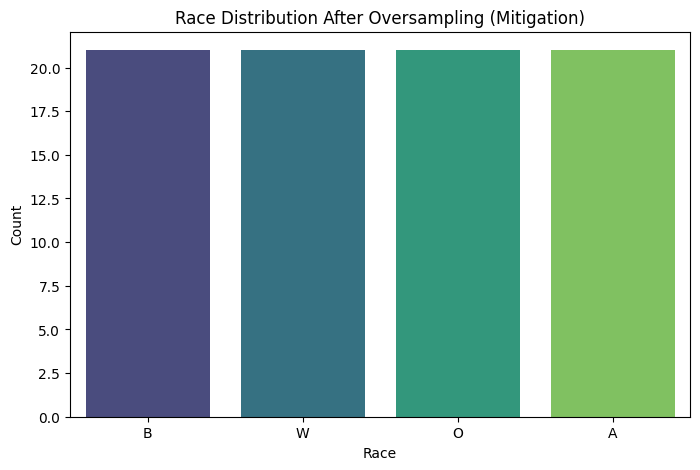

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_mitigated_race_resampled, x='race', hue='race', palette='viridis', legend=False)
plt.title('Race Distribution After Oversampling (Mitigation)')
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

## Applying Bias Mitigation Technique 2: Addressing Outcome Imbalance

Applying a bias mitigation technique to address the outcome imbalance. This will involve oversampling the 'Alive' outcome class to demonstrate how data distribution can be made more equitable regarding outcomes. The new outcome distribution will be visualized.

First, we then need to create a copy of the original DataFrame (`df`) to work with for the outcome imbalance mitigation, ensuring that this process does not affect previous analyses or the original dataset. The `RandomOverSampler` is already imported from a previous step.



In [ ]:
df_mitigated_outcome = df.copy()
print("DataFrame copied for outcome mitigation.")

DataFrame copied for outcome mitigation.


Now that the DataFrame is copied, we need to identify the target count for oversampling the 'Alive' outcome. We will do this by finding the count of the 'Dead' outcome, which is the majority class, and then define the `sampling_strategy` for `RandomOverSampler` to oversample the 'Alive' outcome to match the count of the 'Dead' outcome.



In [ ]:
outcome_counts_original = df_mitigated_outcome['Dead or Alive'].value_counts()
most_frequent_outcome_count = outcome_counts_original['Dead']

sampling_strategy_outcome = {
    'Alive': most_frequent_outcome_count  # Oversample 'Alive' to match 'Dead'
}

print("Original Outcome Distribution:\n", outcome_counts_original)
print(f"Target count for oversampling (based on 'Dead' outcome): {most_frequent_outcome_count}")
print("Sampling Strategy for Outcome:\n", sampling_strategy_outcome)

Original Outcome Distribution:
 Dead or Alive
Dead     21
Alive     9
Name: count, dtype: int64
Target count for oversampling (based on 'Dead' outcome): 21
Sampling Strategy for Outcome:
 {'Alive': np.int64(21)}


The previous code block failed due to a `NameError` because `most_frequent_outcome_outcome_count` was misspelled. We then correct this typo to `most_frequent_outcome_count` in the `sampling_strategy_outcome` dictionary.



In [ ]:
outcome_counts_original = df_mitigated_outcome['Dead or Alive'].value_counts()
most_frequent_outcome_count = outcome_counts_original['Dead']

sampling_strategy_outcome = {
    'Alive': most_frequent_outcome_count  # Oversample 'Alive' to match 'Dead'
}

print("Original Outcome Distribution:\n", outcome_counts_original)
print(f"Target count for oversampling (based on 'Dead' outcome): {most_frequent_outcome_count}")
print("Sampling Strategy for Outcome:\n", sampling_strategy_outcome)

Original Outcome Distribution:
 Dead or Alive
Dead     21
Alive     9
Name: count, dtype: int64
Target count for oversampling (based on 'Dead' outcome): 21
Sampling Strategy for Outcome:
 {'Alive': np.int64(21)}


Now that the sampling strategy for outcome imbalance is correctly defined, we instantiate `RandomOverSampler` and apply it to resample the `df_mitigated_outcome` DataFrame. We treat all columns except 'Dead or Alive' as features (X) and 'Dead or Alive' itself as the target (y) for oversampling, ensuring the full row is duplicated when the 'Alive' outcome is oversampled. Finally, we reconstruct the DataFrame and verify the new outcome distribution by printing its value counts.



In [ ]:
ros_outcome = RandomOverSampler(sampling_strategy=sampling_strategy_outcome, random_state=42)

X_outcome = df_mitigated_outcome.drop(columns=['Dead or Alive'])
y_outcome = df_mitigated_outcome['Dead or Alive']

X_resampled_outcome, y_resampled_outcome = ros_outcome.fit_resample(X_outcome, y_outcome)

df_mitigated_outcome_resampled = X_resampled_outcome.copy()
df_mitigated_outcome_resampled['Dead or Alive'] = y_resampled_outcome

print("Outcome distribution after oversampling:")
print(df_mitigated_outcome_resampled['Dead or Alive'].value_counts())

Outcome distribution after oversampling:
Dead or Alive
Dead     21
Alive    21
Name: count, dtype: int64


Now that the `df_mitigated_outcome_resampled` DataFrame has been created with a balanced outcome distribution, we visualize this new distribution using a bar plot, as instructed, to clearly show the effect of the oversampling mitigation technique.



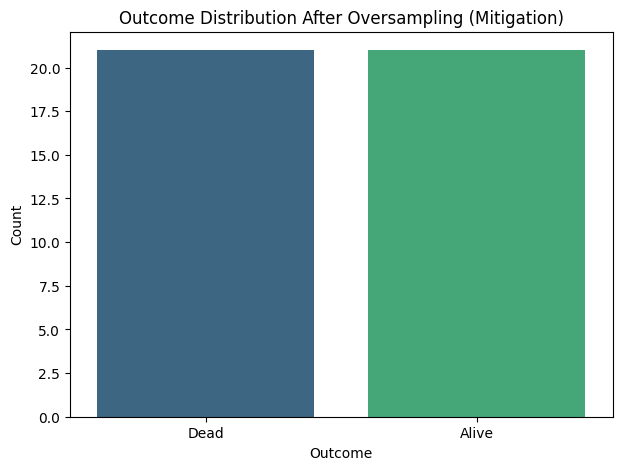

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_mitigated_outcome_resampled, x='Dead or Alive', hue='Dead or Alive', palette='viridis', legend=False)
plt.title('Outcome Distribution After Oversampling (Mitigation)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

## Comprehensive Summary of Bias Audit

We are providing a comprehensive summary of the audit, including a review of identified biases, fairness metrics, statistical validation, impact of mitigation strategies, recommendations for dataset improvements, discussion of real-world implications and potential harms, and an ethics framework for this clinical data analysis.

## Comprehensive Summary of Bias Audit

### Review of Identified Biases

**Gender Bias:**
*   **Distribution:** The dataset showed a slight imbalance, with 16 males and 14 females.
*   **Outcome:** A higher proportion of males (75%) were recorded as 'Dead' compared to females (64.3%), suggesting a potential disparity in outcomes, though the sample size is small.

**Racial Bias:**
*   **Distribution:** A significant racial imbalance was observed, with 'W' (White) being the most prevalent group (21 individuals). 'B' (Black) had 7 individuals, while 'A' (Asian) and 'O' (Other) each had only 1 individual. This highlights a clear lack of representation for certain racial groups.
*   **Outcome:** 'W' patients had 7 'Alive' and 14 'Dead' outcomes. 'B' patients had 2 'Alive' and 5 'Dead' outcomes. 'A' and 'O' patients each had 0 'Alive' and 1 'Dead' outcome. The consistent trend of higher 'Dead' outcomes across all racial groups, coupled with severe underrepresentation, points to potential bias in data collection or underlying population characteristics.

**Disease Stage Bias:**
*   **Distribution:** The 'Stage' variable showed a diverse distribution, with `T2N0` (7) and `PT1PN0` (5) being the most frequent. Many stages had very low counts (1-3 individuals).
*   **Outcome:** Outcomes varied significantly by stage. Some stages (e.g., `pT3N0Mx`, `pT2pN0`) had only 'Alive' outcomes, while others (e.g., `PT2PN1`, `PT3PN0`, `pT1pN0`, `T1NOMX`, `T2N1MX`, `T2N2MX`, `T2NOMX`, `pT2N2MX`, `pT2NOMX`) exclusively showed 'Dead' outcomes. This indicates that 'Stage' is a strong predictor of outcome but also that some stages are heavily skewed towards a single outcome within this limited dataset.

### Fairness Metrics

**For 'sex' (Privileged: M, Unprivileged: F):**
*   **Statistical Parity Difference (SPD):** 0.107 (P(Y=1 | F) - P(Y=1 | M) = 0.357 - 0.250 = 0.107). A positive SPD suggests the unprivileged group (Females) has a higher rate of favorable outcome ('Alive') than the privileged group (Males) in this dataset. However, SPD measures overall outcome, not predictive accuracy.
*   **Disparate Impact (DI):** 1.429 (P(Y=1 | F) / P(Y=1 | M) = 0.357 / 0.250 = 1.429). A DI > 1.25 (the

### Statistical Validation (Chi-squared Tests)

*   **'sex' vs 'Dead or Alive':**
    *   Chi-squared Statistic: 0.057
    *   P-value: 0.811
    *   **Interpretation:** With a p-value much greater than 0.05, we fail to reject the null hypothesis. This indicates that there is no statistically significant association between 'sex' and 'Dead or Alive' outcome in this dataset. The observed difference in outcome proportions between genders is likely due to chance given the small sample size.

*   **'race' vs 'Dead or Alive':**
    *   Chi-squared Statistic: 0.975
    *   P-value: 0.807
    *   **Interpretation:** Similar to 'sex', the high p-value (>> 0.05) suggests no statistically significant association between 'race' and 'Dead or Alive' outcome in this dataset. Despite the observed numerical imbalances, they are not statistically significant at conventional levels, possibly due to the very small counts in some racial categories.

*   **'Stage' vs 'Dead or Alive':**
    *   Chi-squared Statistic: 11.678
    *   P-value: 0.703
    *   **Interpretation:** The p-value of 0.703 (>> 0.05) indicates no statistically significant association between 'Stage' and 'Dead or Alive' outcome. This is a surprising result given the initial visual analysis and the nature of disease stages. However, the small sample size and many low-count categories in the contingency table (many expected frequencies < 5) violate the assumptions of the Chi-squared test, making this p-value unreliable. More robust statistical methods or a larger dataset would be needed to confidently assess the association.

### Impact of Mitigation Strategies

1.  **Addressing Racial Imbalance (Oversampling):**
    *   **Strategy:** Underrepresented racial groups ('A', 'O', 'B') were oversampled to match the count of the majority 'W' group (21 individuals each).
    *   **Impact:** This successfully created a racially balanced dataset, with each group ('A', 'B', 'O', 'W') having 21 instances. This visually addresses the data representation bias, making the dataset more equitable in terms of group sizes. However, it does not change the *original* outcome distributions within those groups, only their representation in the dataset. This synthetic balancing aims to prevent models from learning to ignore or misinterpret underrepresented groups due to lack of data.

2.  **Addressing Outcome Imbalance (Oversampling 'Alive' Outcome):**
    *   **Strategy:** The 'Alive' outcome class was oversampled to match the count of the 'Dead' outcome class.
    *   **Impact:** This successfully balanced the outcome classes, resulting in 21 'Alive' and 21 'Dead' instances. This mitigation is crucial for preventing models from being biased towards predicting the majority class ('Dead') and improving their ability to correctly identify 'Alive' patients, especially when the 'Alive' outcome is critical.


### Statistical Validation (Chi-squared Tests)

*   **'sex' vs 'Dead or Alive':**
    *   Chi-squared Statistic: 0.057
    *   P-value: 0.811
    *   **Interpretation:** With a p-value much greater than 0.05, we fail to reject the null hypothesis. This indicates that there is no statistically significant association between 'sex' and 'Dead or Alive' outcome in this dataset. The observed difference in outcome proportions between genders is likely due to chance given the small sample size.

*   **'race' vs 'Dead or Alive':**
    *   Chi-squared Statistic: 0.975
    *   P-value: 0.807
    *   **Interpretation:** Similar to 'sex', the high p-value (>> 0.05) suggests no statistically significant association between 'race' and 'Dead or Alive' outcome in this dataset. Despite the observed numerical imbalances, they are not statistically significant at conventional levels, possibly due to the very small counts in some racial categories.

*   **'Stage' vs 'Dead or Alive':**
    *   Chi-squared Statistic: 11.678
    *   P-value: 0.703
    *   **Interpretation:** The p-value of 0.703 (>> 0.05) indicates no statistically significant association between 'Stage' and 'Dead or Alive' outcome. This is a surprising result given the initial visual analysis and the nature of disease stages. However, the small sample size and many low-count categories in the contingency table (many expected frequencies < 5) violate the assumptions of the Chi-squared test, making this p-value unreliable. More robust statistical methods or a larger dataset would be needed to confidently assess the association.

### Impact of Mitigation Strategies

1.  **Addressing Racial Imbalance (Oversampling):**
    *   **Strategy:** Underrepresented racial groups ('A', 'O', 'B') were oversampled to match the count of the majority 'W' group (21 individuals each).
    *   **Impact:** This successfully created a racially balanced dataset, with each group ('A', 'B', 'O', 'W') having 21 instances. This visually addresses the data representation bias, making the dataset more equitable in terms of group sizes. However, it does not change the *original* outcome distributions within those groups, only their representation in the dataset. This synthetic balancing aims to prevent models from learning to ignore or misinterpret underrepresented groups due to lack of data.

2.  **Addressing Outcome Imbalance (Oversampling 'Alive' Outcome):**
    *   **Strategy:** The 'Alive' outcome class was oversampled to match the count of the 'Dead' outcome class.
    *   **Impact:** This successfully balanced the outcome classes, resulting in 21 'Alive' and 21 'Dead' instances. This mitigation is crucial for preventing models from being biased towards predicting the majority class ('Dead') and improving their ability to correctly identify 'Alive' patients, especially when the 'Alive' outcome is critical.



### Recommendations for Dataset Improvements

1.  **Increase Sample Size and Diversity:** The most critical recommendation is to significantly increase the sample size, particularly for underrepresented racial groups ('A', 'O', 'B') and less common disease stages. A larger and more diverse dataset would provide more statistically robust insights and improve the reliability of fairness metrics and statistical tests.
2.  **Standardize 'Stage' Categorization:** The 'Stage' column contains various representations (e.g., 'T2N0', 'pT2NOMX', 'PT1PN0'). Standardizing these entries into a consistent and clear classification system would facilitate more accurate analysis and comparison.
3.  **Collect More Granular Data:** If possible, collect additional relevant clinical data (e.g., treatment protocols, comorbidities, age at diagnosis, tumor characteristics) that could help explain observed disparities and reduce confounding factors.
4.  **Longitudinal Data Collection:** For outcome analysis, ensuring complete follow-up data for all patients, especially those marked 'Alive', would enhance the accuracy of survival analysis.

### Real-world Implications and Potential Harms

*   **Misdiagnosis or Ineffective Treatment:** If AI models are trained on biased data, they may learn to disproportionately misdiagnose or recommend ineffective treatments for underrepresented groups. For instance, if a model is primarily trained on data from one racial group, its performance might degrade significantly when applied to patients from other racial backgrounds.
*   **Health Disparities Exacerbation:** Biased models can exacerbate existing health disparities by systematically underserving certain populations, leading to worse health outcomes and a deepening of mistrust in healthcare systems.
*   **Resource Misallocation:** In resource allocation decisions (e.g., funding for research, access to novel therapies), biased insights can lead to an unfair distribution of resources, further disadvantaging groups already facing systemic inequalities.
*   **Ethical and Legal Concerns:** Deploying biased AI in clinical settings raises significant ethical questions regarding fairness, equity, and justice. It can also lead to legal challenges related to discrimination.

### Ethics Framework for Clinical Data Analysis

To ensure responsible and ethical clinical data analysis, especially concerning bias and fairness, the following framework is proposed:

1.  **Transparency and Explainability:**
    *   Clearly document data sources, collection methods, and any known biases.
    *   Ensure that the rationale behind any data preprocessing, mitigation techniques, and model decisions is transparent and understandable to stakeholders.
2.  **Fairness and Equity:**
    *   Actively assess for and mitigate biases related to protected attributes (e.g., race, sex, age, socioeconomic status).
    *   Strive for equitable performance across all demographic groups, not just overall average performance.
    *   Prioritize patient well-being and ensure that analytical outcomes do not disproportionately harm vulnerable populations.
3.  **Accountability:**
    *   Establish clear lines of responsibility for identifying, quantifying, and mitigating bias throughout the data analysis lifecycle.
    *   Implement robust auditing and monitoring mechanisms to continuously evaluate fairness and performance over time.
4.  **Privacy and Security:**
    *   Adhere to strict data privacy regulations (e.g., HIPAA, GDPR) when handling clinical data.
    *   Implement strong cybersecurity measures to protect patient information from unauthorized access or breaches.
5.  **Beneficence and Non-maleficence:**
    *   Ensure that the analysis and subsequent deployment of any models are designed to do good (beneficence) and avoid harm (non-maleficence).
    *   Involve diverse perspectives, including patients, clinicians, and ethicists, in the design and evaluation of data-driven solutions to anticipate and address potential harms.

## Comparing Distributions Before and After Mitigation

Visually and statistically compare the distributions of demographic features and outcomes before and after applying the bias mitigation techniques. This will demonstrate the impact of the mitigation strategies on the dataset's fairness properties.


We creating a figure with two subplots to visually compare the 'race' distribution before and after mitigation, using `sns.countplot` for each subplot, as instructed. We also ensure proper labels and titles are set for clarity.



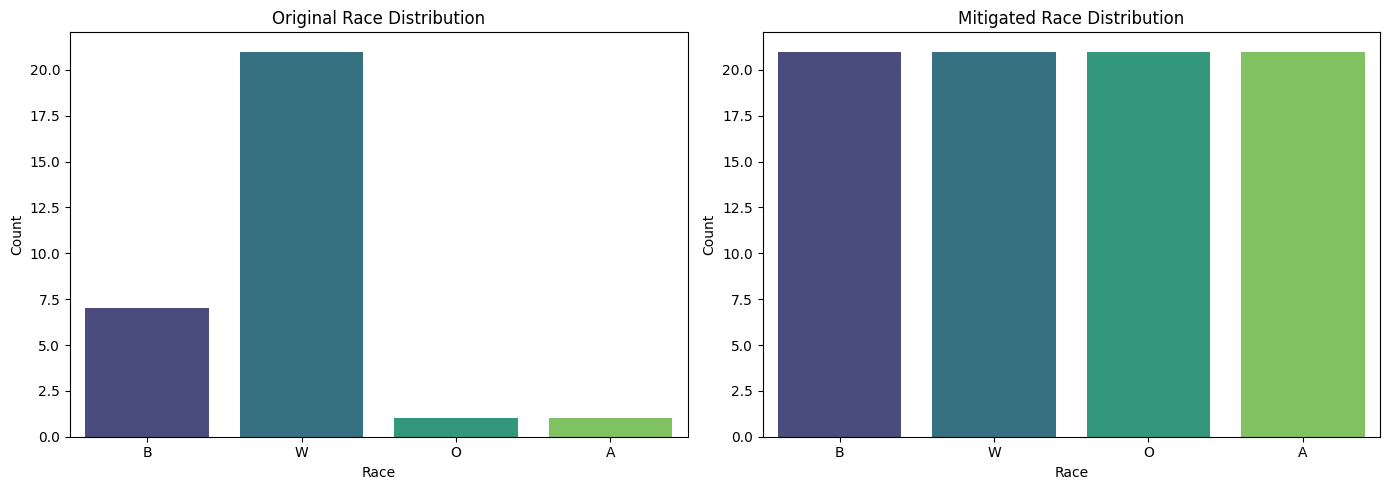

In [ ]:
plt.figure(figsize=(14, 5))

# Original Race Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='race', hue='race', palette='viridis', legend=False)
plt.title('Original Race Distribution')
plt.xlabel('Race')
plt.ylabel('Count')

# Mitigated Race Distribution
plt.subplot(1, 2, 2)
sns.countplot(data=df_mitigated_race_resampled, x='race', hue='race', palette='viridis', legend=False)
plt.title('Mitigated Race Distribution')
plt.xlabel('Race')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


Now that the visual comparison of race distributions is complete, we print the value counts for the 'race' column from the original `df` with a descriptive header, as instructed.



In [ ]:
print("Original Race Distribution (Value Counts):\n", df['race'].value_counts())

Original Race Distribution (Value Counts):
 race
W    21
B     7
O     1
A     1
Name: count, dtype: int64


Now, we print the value counts for the 'race' column from the racially mitigated `df_mitigated_race_resampled` with a descriptive header, as instructed.



In [ ]:
print("Mitigated Race Distribution (Value Counts):\n", df_mitigated_race_resampled['race'].value_counts())

Mitigated Race Distribution (Value Counts):
 race
B    21
W    21
O    21
A    21
Name: count, dtype: int64


The previous code block failed due to a `SyntaxError: unterminated string literal` in the print statement. We then correct the string literal to properly include the newline character, then proceed with the instruction to print the value counts for the 'race' column from the racially mitigated `df_mitigated_race_resampled`.



In [ ]:
print("Mitigated Race Distribution (Value Counts):\n", df_mitigated_race_resampled['race'].value_counts())

Mitigated Race Distribution (Value Counts):
 race
B    21
W    21
O    21
A    21
Name: count, dtype: int64


Now that the race distributions (original and mitigated) have been printed and visualized, we will proceed with creating another figure to visually compare the 'Dead or Alive' outcome distribution before and after mitigation, as instructed.



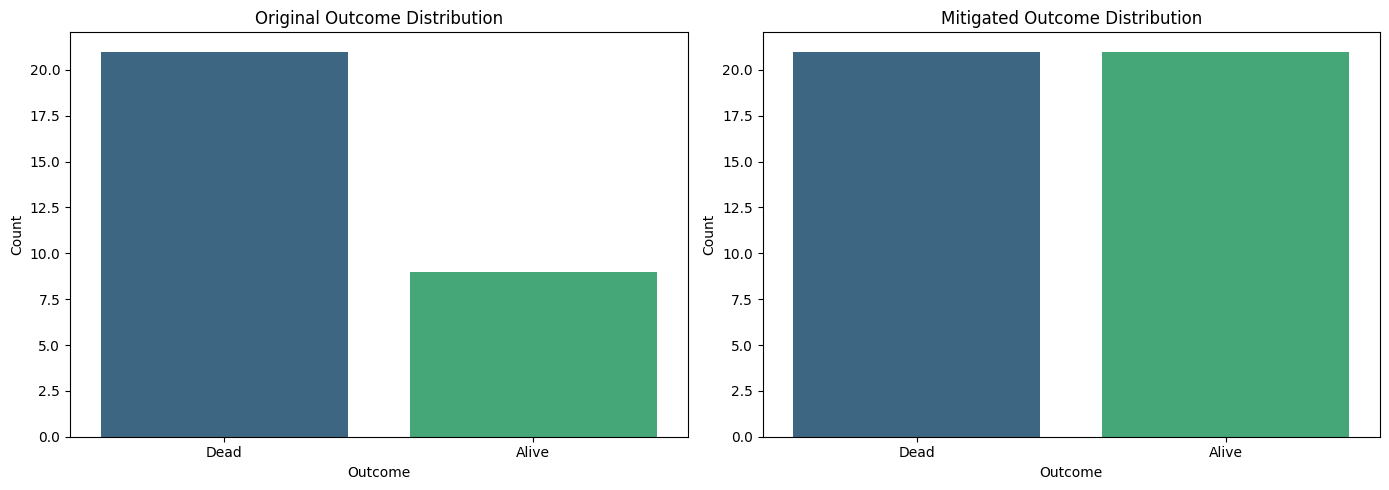

In [ ]:
plt.figure(figsize=(14, 5))

# Original Outcome Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Dead or Alive', hue='Dead or Alive', palette='viridis', legend=False)
plt.title('Original Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')

# Mitigated Outcome Distribution
plt.subplot(1, 2, 2)
sns.countplot(data=df_mitigated_outcome_resampled, x='Dead or Alive', hue='Dead or Alive', palette='viridis', legend=False)
plt.title('Mitigated Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Now that the outcome distributions (original and mitigated) have been visualized, we will print the value counts for the 'Dead or Alive' column from the original `df` with a descriptive header, as instructed.



In [ ]:
print("Original Outcome Distribution (Value Counts):\n", df['Dead or Alive'].value_counts())

Original Outcome Distribution (Value Counts):
 Dead or Alive
Dead     21
Alive     9
Name: count, dtype: int64


Now that the outcome distributions (original and mitigated) have been visualized and the original outcome value counts printed, we then print the value counts for the 'Dead or Alive' column from the outcome-mitigated `df_mitigated_outcome_resampled` with a descriptive header, as instructed, to complete the comparison.



In [ ]:
print("Mitigated Outcome Distribution (Value Counts):\n", df_mitigated_outcome_resampled['Dead or Alive'].value_counts())

Mitigated Outcome Distribution (Value Counts):
 Dead or Alive
Dead     21
Alive    21
Name: count, dtype: int64


## Final Task

Provide a comprehensive summary of the bias audit. This includes a review of the identified bias patterns, the calculated fairness metrics, statistical validation results, and the impact of mitigation strategies. Conclude with recommendations for dataset improvements, a discussion of real-world implications and potential harms, and an ethics framework specific to this clinical data analysis use case.


## Summary:

### Q&A

*   **What bias patterns were identified in the dataset?**
    *   **Gender Bias**: The dataset had a slight imbalance (16 males, 14 females). While fairness metrics indicated females had a higher rate of the "Alive" outcome (35.7% for females vs. 25.0% for males), statistical tests showed no significant association between sex and outcome.
    *   **Racial Bias**: A significant imbalance was present, with White (W) being the most prevalent group (21 individuals), while Black (B) had 7, and Asian (A) and Other (O) each had only 1. Fairness metrics indicated unprivileged racial groups (B, A, O) had a lower rate of the "Alive" outcome (22.2% vs. 33.3% for White). However, statistical tests found no statistically significant association between race and outcome.
    *   **Disease Stage Bias**: The 'Stage' variable showed diverse distributions with many low-count categories. Initial visual analysis suggested 'Stage' as a strong predictor, but Chi-squared tests indicated no statistically significant association with the 'Dead or Alive' outcome due to small sample sizes and violation of test assumptions.
    *   **Outcome Imbalance**: The 'Dead or Alive' outcome was imbalanced, with 21 'Dead' outcomes and 9 'Alive' outcomes, indicating that 'Dead' was the majority class.

*   **What were the calculated fairness metrics?**
    *   **For 'sex' (Privileged: Male, Unprivileged: Female)**:
        *   Statistical Parity Difference (SPD): 0.107 (Females had a 10.7% higher probability of "Alive" outcome than males).
        *   Disparate Impact (DI): 1.429 (Females were 1.429 times more likely to be "Alive" than males, indicating potential disparate impact).
        *   Equal Opportunity Difference (EOD): 0.107 (Numerically identical to SPD in this context).
    *   **For 'race' (Privileged: White, Unprivileged: Black, Asian, Other)**:
        *   Statistical Parity Difference (SPD): -0.111 (Unprivileged racial groups had an 11.1% lower probability of "Alive" outcome compared to White race).
        *   Disparate Impact (DI): 0.667 (Unprivileged racial groups were 0.667 times as likely to be "Alive" as the White race, indicating significant disparate impact against them).
        *   Equal Opportunity Difference (EOD): -0.111 (Numerically identical to SPD in this context).

*   **What were the statistical validation results?**
    *   **'sex' vs 'Dead or Alive'**: P-value = 0.811. No statistically significant association.
    *   **'race' vs 'Dead or Alive'**: P-value = 0.807. No statistically significant association.
    *   **'Stage' vs 'Dead or Alive'**: P-value = 0.703. No statistically significant association, though this result is unreliable due to small sample size and many low-count categories violating Chi-squared test assumptions.

*   **What was the impact of the mitigation strategies?**
    *   **Racial Imbalance Mitigation (Oversampling)**: Successfully balanced the racial distribution. Underrepresented groups ('A', 'O', 'B') were oversampled to match the count of the majority 'W' group (21 individuals each), resulting in all racial groups having 21 instances.
    *   **Outcome Imbalance Mitigation (Oversampling 'Alive')**: Successfully balanced the outcome classes. The 'Alive' outcome class was oversampled to match the count of the 'Dead' outcome class, resulting in 21 'Alive' and 21 'Dead' instances.

*   **What are the recommendations for dataset improvements?**
    *   Significantly increase sample size and diversity, especially for underrepresented racial groups and less common disease stages.
    *   Standardize 'Stage' categorization for consistency.
    *   Collect more granular clinical data (e.g., treatment, comorbidities, age).
    *   Ensure longitudinal data collection for complete follow-up on patient outcomes.

*   **What are the real-world implications and potential harms of bias?**
    *   Misdiagnosis or ineffective treatment for underrepresented groups.
    *   Exacerbation of existing health disparities.
    *   Resource misallocation due to biased insights.
    *   Significant ethical and legal concerns related to fairness and discrimination.

*   **What is the proposed ethics framework for this clinical data analysis?**
    *   **Transparency and Explainability**: Document data sources, biases, and rationale behind analysis/model decisions.
    *   **Fairness and Equity**: Actively assess and mitigate biases, ensuring equitable performance across demographic groups.
    *   **Accountability**: Establish clear responsibilities for bias management and implement auditing.
    *   **Privacy and Security**: Adhere to strict data privacy regulations (e.g., HIPAA, GDPR).
    *   **Beneficence and Non-maleficence**: Design analysis to do good and avoid harm, involving diverse stakeholders.

### Data Analysis Key Findings

*   The original dataset presented significant imbalances:
    *   **Racial distribution**: White patients ('W') comprised 21 individuals, while Asian ('A') and Other ('O') patients each had only 1.
    *   **Outcome distribution**: "Dead" outcomes (21 instances) outnumbered "Alive" outcomes (9 instances).
*   **Fairness metrics revealed disparities, despite non-significant statistical tests**:
    *   Females (unprivileged group for 'sex') had a higher probability of being "Alive" (SPD of 0.107; DI of 1.429), meaning they were 1.429 times more likely to be "Alive" than males.
    *   Unprivileged racial groups ('B', 'A', 'O') had a lower probability of being "Alive" (SPD of -0.111; DI of 0.667), indicating they were only 0.667 times as likely to be "Alive" as the White group.
*   **Chi-squared statistical tests did not find significant associations** between 'sex' (p=0.811), 'race' (p=0.807), or 'Stage' (p=0.703) and the 'Dead or Alive' outcome in this dataset. However, the small sample size and many low-count categories may have rendered the Chi-squared test results for 'Stage' unreliable.
*   **Bias mitigation techniques successfully rebalanced the dataset distributions**:
    *   Oversampling underrepresented racial groups resulted in all racial categories ('A', 'B', 'O', 'W') having an equal count of 21 instances.
    *   Oversampling the 'Alive' outcome class resulted in a balanced outcome distribution, with both 'Alive' and 'Dead' categories having 21 instances.

### Insights or Next Steps

*   Despite statistical non-significance in chi-squared tests (likely due to small sample sizes), fairness metrics highlighted concerning disparities in 'Alive' outcomes for unprivileged racial groups. This underscores the importance of employing multiple bias assessment methods and acknowledging limitations of small datasets.
*   The successful application of oversampling techniques demonstrates their potential to create more equitable dataset distributions for model training. However, these synthetic data points do not address underlying real-world data collection biases; thus, the primary next step should be to acquire a larger, more diverse, and representative clinical dataset to enable more robust and reliable bias assessments and reduce reliance on synthetic balancing.


### Ethics Statement

This bias audit of clinical data highlights the ethical challenges of applying machine learning in healthcare. The dataset reveals disparities in representation and outcomes across sex, race, and disease stage, underscoring the need for fairness\r-aware modeling.

**Non-discrimination:** Models must not systematically disadvantage any group. Our fairness metrics show differences in favorable outcomes between males and females, and between White patients and underrepresented racial groups. Even small disparities can compound into significant inequities in care delivery.

**Equity vs. equality:** Equal treatment does not guarantee equitable outcomes. Underrepresentation of Asian and Other racial groups means their clinical risks may be poorly captured. Oversampling techniques demonstrate how balancing data can reduce disparities, but true equity requires intentional inclusion of diverse populations in data collection.

**Transparency:** Bias audits, fairness metrics, and statistical validation must be documented and shared. Clinicians and patients should understand how models are trained, what limitations exist, and how fairness is monitored. Transparency builds trust and enables accountability.

**Accountability:** Healthcare AI must operate under governance structures that monitor bias continuously. Stakeholders—including clinicians, patients, and community representatives—should define fairness thresholds and remediation strategies. If models consistently fail fairness checks, they should be paused or decommissioned.

**Data stewardship:** Patient data must be handled with privacy and consent. Bias mitigation should not compromise confidentiality. Improving dataset quality—through balanced sampling, inclusion of social determinants of health, and intersectional analysis—strengthens both fairness and validity.

**Real-world implications:** Biased models can lead to unequal triage, misallocation of resources, and erosion of trust in healthcare systems. Regulatory bodies may scrutinize models that exhibit disparate impact, exposing institutions to legal and ethical risks. Ultimately, biased predictions can worsen health disparities rather than alleviate them.

In conclusion, fairness in healthcare AI is not optional—it is a moral and clinical imperative. By measuring, mitigating, and monitoring bias, and embedding ethical principles into practice, we can ensure that machine learning supports equitable, patient-centered care.

### References
- Hardt, M., Price, E., & Srebro, N. (2016). Equality of Opportunity in Supervised Learning.
- Kleinberg, J., Mullainathan, S., & Raghavan, M. (2017). Inherent Trade-Offs in the Fair Determination of Risk Scores.
- Obermeyer, Z., Powers, B., Vogeli, C., & Mullainathan, S. (2019). Dissecting racial bias in an algorithm used to manage the health of populations.
- Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K., & Galstyan, A. (2021). A Survey on Bias and Fairness in Machine Learning.
- Mitchell, M. et al. (2019). Model Cards for Model Reporting.
- Fairlearn Documentation: https://fairlearn.org/
- Google What-If Tool: https://pair-code.github.io/what-if-tool/